This notebook continues from 02_data_analysis.ipynb and 03_yolo_test.ipynb.

What we learned so far:
- Smoke is rarer and harder to detect than fire.
- Many boxes are small.
- Some smoke images are hard due to sunlight, snow, or low contrast.
- Mosaic was basically off during the 03 baseline run.

A literature check suggested keeping geometric transforms and mild color jitter, while avoiding vertical flip, large rotations, grayscale, and strong hue/blur changes for a fixed indoor camera

Four transforms usable by both methods horizontal flip, limited color jitter, random scaling, and CLAHE (targets low-contrast smoke). Mosaic stays a YOLO training config option.

In [2]:
import random
import sys
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance

In [3]:
PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))
from helpers.viz import draw_bbox
DATA_DIR = PROJECT_ROOT / "data"

In [4]:
def load_yolo_boxes(label_path: Path):
    text = label_path.read_text().strip()
    boxes = []
    for line in text.splitlines():
        cls_id, xc, yc, w, h = map(float, line.split())
        boxes.append((int(cls_id), xc, yc, w, h))
    return boxes

In [5]:
sample_label = DATA_DIR / "train" / "labels" / "train_1.txt"
boxes = load_yolo_boxes(sample_label)
boxes

[(0, 0.60703125, 0.6555555555555556, 0.05625, 0.08333333333333334)]

We also need a drawer that takes boxes from a Python list, not only from a label file augmentations will change boxes in memory. We added a new function to helpers/viz.py

In [6]:
from helpers.viz import draw_yolo_boxes
img_path = DATA_DIR / "train" / "images" / "train_1.jpg"
label_path = DATA_DIR / "train" / "labels" / "train_1.txt"

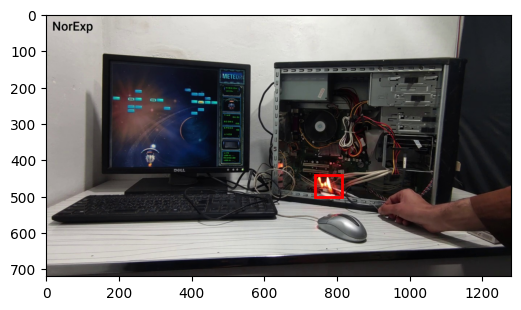

In [7]:
img = Image.open(img_path).convert("RGB")
boxes = load_yolo_boxes(label_path)
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(img)
draw_yolo_boxes(ax, boxes, img.width, img.height)
plt.show()

Flip the image left-right with probability 0.5 and mirror x_center so boxes stay on the objects

In [8]:
def horizontal_flip(img: Image.Image, boxes, p=0.5):
    if random.random() >= p:
        return img, boxes
    img = img.transpose(Image.FLIP_LEFT_RIGHT)
    boxes = [(cls_id, 1.0 - xc, yc, w, h) for cls_id, xc, yc, w, h in boxes]
    return img, boxes

In [9]:
img_path = DATA_DIR / "train" / "images" / "train_1.jpg"
label_path = DATA_DIR / "train" / "labels" / "train_1.txt"

img = Image.open(img_path).convert("RGB")
boxes = load_yolo_boxes(label_path)
boxes

[(0, 0.60703125, 0.6555555555555556, 0.05625, 0.08333333333333334)]

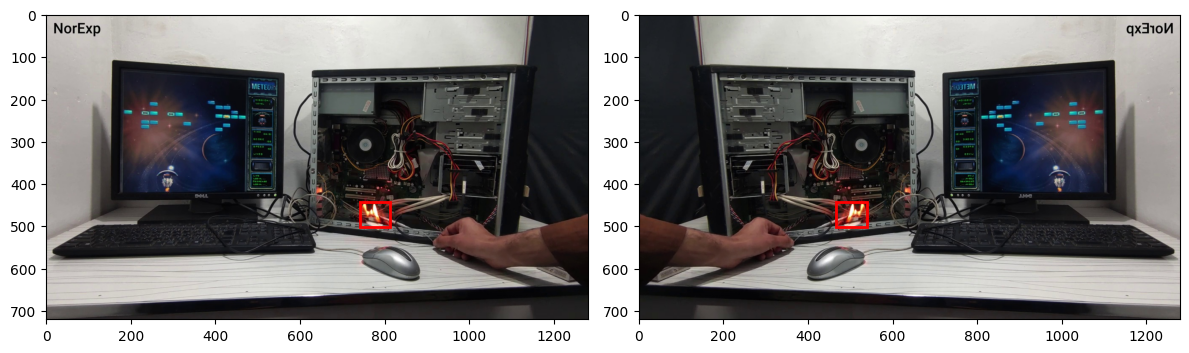

In [10]:
flipped_img, flipped_boxes = horizontal_flip(img.copy(), boxes, p=1.0)
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img)
draw_yolo_boxes(axes[0], boxes, img.width, img.height)
axes[1].imshow(flipped_img)
draw_yolo_boxes(axes[1], flipped_boxes, flipped_img.width, flipped_img.height)
plt.tight_layout()
plt.show()

Horizontal flip works the scene is mirrored and the fire box moves with the flame. Box size and vertical position stay the same.

We will make color jitter: change brightness, contrast, and saturation a little. We do not touch hue because strong hue shifts can confuse fire and smoke. Boxes stay the same.

In [11]:
def limited_color_jitter(img: Image.Image, brightness=0.15, contrast=0.15, saturation=0.15):
    img = ImageEnhance.Brightness(img).enhance(random.uniform(1 - brightness, 1 + brightness))
    img = ImageEnhance.Contrast(img).enhance(random.uniform(1 - contrast, 1 + contrast))
    img = ImageEnhance.Color(img).enhance(random.uniform(1 - saturation, 1 + saturation))
    return img

Apply jitter a few times on the same image so we can see the range of change

In [12]:
img_path = DATA_DIR / "train" / "images" / "train_4131.jpg"
label_path = DATA_DIR / "train" / "labels" / "train_4131.txt"

img = Image.open(img_path).convert("RGB")
boxes = load_yolo_boxes(label_path)

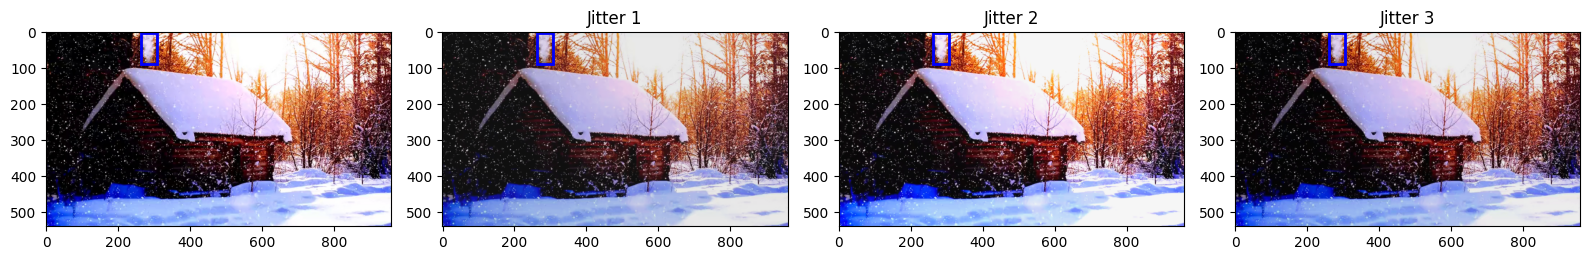

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(img)
draw_yolo_boxes(axes[0], boxes, img.width, img.height)

for i, ax in enumerate(axes[1:], start=1):
    jittered = limited_color_jitter(img.copy())
    ax.imshow(jittered)
    draw_yolo_boxes(ax, boxes, jittered.width, jittered.height)
    ax.set_title(f"Jitter {i}")
plt.tight_layout()
plt.show()

brightness, contrast and saturation change mildly while the smoke box stays in the same place. Good fit for hard lighting cases without breaking labels as literature review says

Resize the image by a random factor YOLO boxes are normalized, so after a uniform resize they stay valid. No remapping needed. Letterbox comes later in preprocessing.

In [14]:
def random_scale(img: Image.Image, boxes, scale_range=(0.8, 1.25)):
    s = random.uniform(*scale_range)
    new_w = max(1, round(img.width * s))
    new_h = max(1, round(img.height * s))
    img = img.resize((new_w, new_h), Image.BILINEAR)
    return img, boxes

Force a few different scales and check that boxes still sit on the objects

In [15]:
img_path = DATA_DIR / "train" / "images" / "train_1.jpg"
label_path = DATA_DIR / "train" / "labels" / "train_1.txt"
img = Image.open(img_path).convert("RGB")
boxes = load_yolo_boxes(label_path)

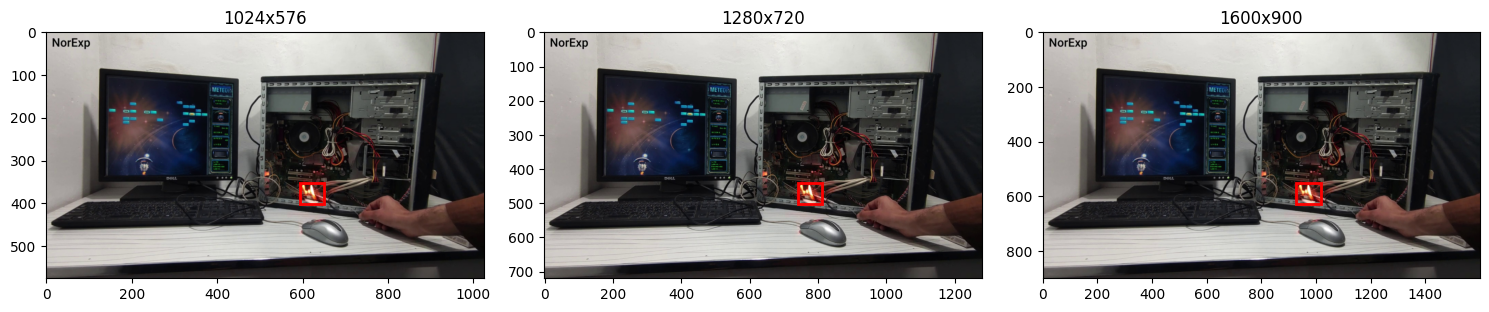

In [16]:
scales = [0.8, 1.0, 1.25]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, s in zip(axes, scales):
    scaled = img.resize(
        (max(1, round(img.width * s)), max(1, round(img.height * s))),
        Image.BILINEAR,
    )
    ax.imshow(scaled)
    draw_yolo_boxes(ax, boxes, scaled.width, scaled.height)
    ax.set_title(f"{scaled.width}x{scaled.height}")
plt.tight_layout()
plt.show()

Random scaling works at 0.8×, 1.0×, and 1.25× the fire box stays on the flame

We did a short literature check on fire/smoke augmentation, and CLAHE kept coming up for low-contrast smoke (sunlight, snow, haze). So we add it here as an optional step

In [ ]:
import cv2
import numpy as np
def apply_clahe(img: Image.Image, clip_limit=2.0, tile_grid_size=(8, 8)):
    arr = np.array(img)
    lab = cv2.cvtColor(arr, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    l_eq = clahe.apply(l)
    lab_eq = cv2.merge((l_eq, a, b))
    rgb_eq = cv2.cvtColor(lab_eq, cv2.COLOR_LAB2RGB)
    return Image.fromarray(rgb_eq)

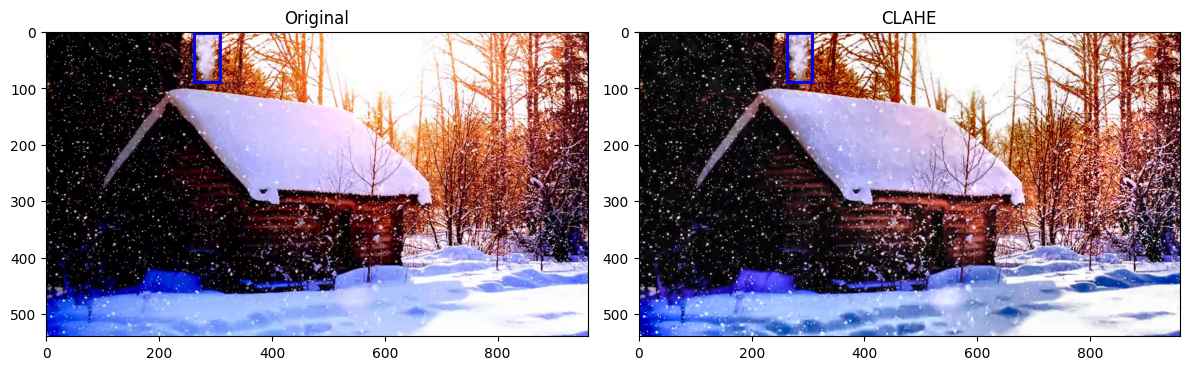

In [18]:
img_path = DATA_DIR / "train" / "images" / "train_4131.jpg"
label_path = DATA_DIR / "train" / "labels" / "train_4131.txt"
img = Image.open(img_path).convert("RGB")
boxes = load_yolo_boxes(label_path)
enhanced = apply_clahe(img)
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img)
draw_yolo_boxes(axes[0], boxes, img.width, img.height)
axes[0].set_title("Original")
axes[1].imshow(enhanced)
draw_yolo_boxes(axes[1], boxes, enhanced.width, enhanced.height)
axes[1].set_title("CLAHE")
plt.tight_layout()
plt.show()

For training we chain the three required transforms. CLAHE stays optional and off by default.

In [19]:
def augment_sample(img: Image.Image, boxes, use_clahe=False):
    img, boxes = horizontal_flip(img, boxes, p=0.5)
    img = limited_color_jitter(img)
    img, boxes = random_scale(img, boxes)
    if use_clahe:
        img = apply_clahe(img)
    return img, boxes

One end-to-end check: original vs a random augmented sample.

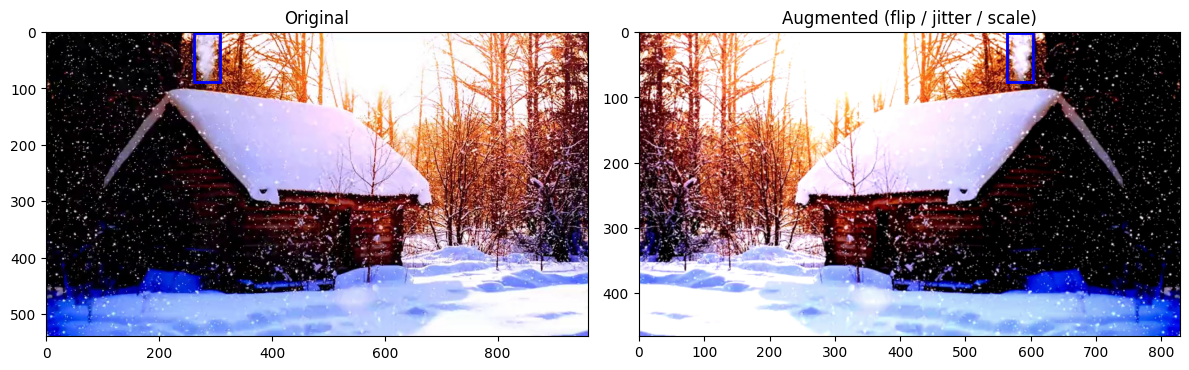

In [25]:
img = Image.open(img_path).convert("RGB")
boxes = load_yolo_boxes(label_path)
aug_img, aug_boxes = augment_sample(img.copy(), boxes)
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img)
draw_yolo_boxes(axes[0], boxes, img.width, img.height)
axes[0].set_title("Original")
axes[1].imshow(aug_img)
draw_yolo_boxes(axes[1], aug_boxes, aug_img.width, aug_img.height)
axes[1].set_title("Augmented (flip / jitter / scale)")
plt.tight_layout()
plt.show()

End to end check looks good, the image is flipped and scaled, colors shift a bit. Required augmentation pipeline is working

Now we will copy all of the augmentation techniques that are implemented to helpers/augmentations.py for the ease of use